In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Machine Learning Project – Comment Category Prediction

Roll Number: ***24f2003468***

Course: Machine Learning Project (MLP)  
Competition: Kaggle Comment Category Prediction Challenge  

## Objective
The objective of this project is to build a machine learning model that can classify online comments into four categories based on their content.

The evaluation metric used in this competition is **Macro F1-score**.


# Data Loading

In [2]:
train=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

In [3]:
train


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197995,2023-02-04 10:39:30.581185+00:00,39,0,0,0,2,0,0,4,NaN,NaN,NaN,False,Why save people who are bent on self-destructi...,0
197996,2023-11-01 17:16:51.337370+00:00,72,0,0,0,1,0,0,10,NaN,NaN,NaN,False,Trudeau is not only undemocratic but also innu...,2
197997,2024-03-09 15:46:22.542539+00:00,72,0,0,0,0,0,0,10,NaN,NaN,NaN,False,block all exports no humanitarian relief and a...,3
197998,2023-08-07 17:23:40.163756+00:00,72,0,1,1,5,7,4,10,black,none,none,False,really black kids seeing that is better than g...,1


In [4]:
train.shape ,test.shape

((198000, 15), (102000, 14))

## Basic Dataset Inspection

In [5]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [6]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [7]:
train.dtypes

created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

In [8]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [9]:
train.isnull().sum()


created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [10]:
train.duplicated().sum()

np.int64(0)

##  Feature Description

| Feature        | Description                  |
| -------------- | ---------------------------- |
| comment        | Text data (main feature)     |
| label          | Target variable (0–3)        |
| upvote         | Number of upvotes            |
| downvote       | Number of downvotes          |
| race           | Identity indicator           |
| religion       | Identity indicator           |
| gender         | Identity indicator           |
| disability     | Identity indicator           |
| emoticon_1,2,3 | Platform-detected emoticons  |
| if_1, if_2     | Internal categorical signals |
| created_date   | Timestamp of comment         |

---


##  Observations

* Missing values present in text and categorical features
* Duplicate entries exist and may need handling
* Text column is the most important feature
* Several categorical features represent identity signals

---

##  Key Insight

This is a **multi-modal dataset**, meaning it contains:

* Text data → requires NLP techniques
* Numerical data → requires scaling
* Categorical data → requires encoding


---

# Exploratory Data Analysis

In [11]:
train["emoticon_1"].unique()

array([ 0,  1, 15,  2,  3,  4,  5, 11,  6,  7,  8, 24, 12, 17, 14, 13,  9,
       10, 20, 16, 25, 18, 21, 19, 23, 36, 22, 28, 27, 33, 30, 46, 32, 47,
       31, 39])

In [12]:
train["post_id"].unique()

array([ 73,  39,  31,  72,  71, 120,  40, 111,  64, 123,  61, 105,  84,
       118,  76,  24,  91,  85, 102,  70,  74,  77,  66,  93, 100,  87,
        83, 103, 101, 108, 115,  79,  89,  75, 104,  90,  95,  96,  67,
       129,  82,  50,  43,  42, 109,  88, 125,  86,  20, 113,  65, 110])

In [13]:
train["emoticon_2"].unique()

array([ 0,  1,  2,  4,  3,  5,  8,  6, 11,  7])

In [14]:
train["emoticon_3"].unique()

array([ 0,  1,  2,  4,  3,  6,  5, 10,  7, 11,  9, 14, 17, 13,  8, 12])

In [15]:
train["race"].unique()

array([nan, 'none', 'white', 'other', 'asian', 'black', 'latino'],
      dtype=object)

In [16]:
train["religion"].unique()

array([nan, 'christian', 'muslim', 'none', 'jewish', 'atheist', 'other',
       'hindu', 'buddhist'], dtype=object)

In [17]:
train["gender"].unique()

array([nan, 'none', 'male', 'female', 'transgender', 'other'],
      dtype=object)

In [18]:
train["label"].unique()

array([2, 0, 1, 3])

In [19]:
train["comment"]

0         She might be a bright spot for a party keou on...
1         Under Alaska law, a non-tribal member is not b...
2         in the future please spare me your strawman dr...
3         PS: That should have been "rot" instead of "co...
4         Today, the confederate flag...tomorrow, the na...
                                ...                        
197995    Why save people who are bent on self-destructi...
197996    Trudeau is not only undemocratic but also innu...
197997    block all exports no humanitarian relief and a...
197998    really black kids seeing that is better than g...
197999    Sounds likely since: "But now scientists have ...
Name: comment, Length: 198000, dtype: object

## Label Analysis

Understanding the distribution of target labels is critical because it directly affects model performance.

In [20]:
train["label"].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [21]:
train["label"].value_counts(normalize=True)

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64

<Axes: xlabel='label', ylabel='count'>

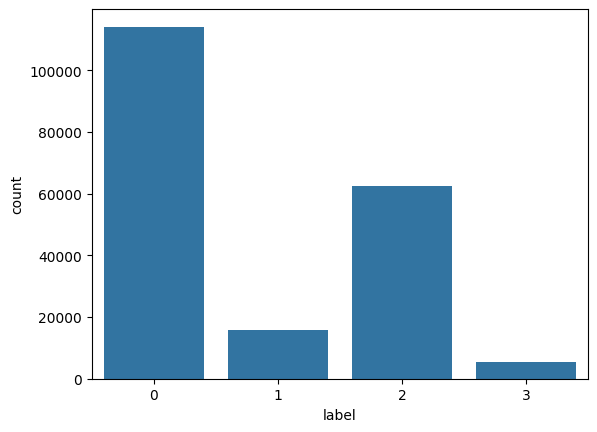

In [22]:
import seaborn as sns

sns.countplot(data=train,x="label")


The bar plot shows a strong class imbalance, with label 0 dominating the dataset and label 3 being severely underrepresented.

- Class **0 dominates (~58%)**
- Class **1 and 2 are moderately represented**
- Class **3 is extremely rare (~2–3%)**

### Problem: Class Imbalance

This dataset suffers from **severe class imbalance**, which can cause:

- Model bias toward majority class (Label 0)
- Poor prediction performance on minority class (Label 3)

## Comment Length Analysis

In [23]:
train['comment_length'] = train['comment'].fillna("").apply(len)
train.groupby('label')['comment_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,114173.0,295.897252,269.586190,0.0,93.0,199.0,411.0,1892.0
1,15918.0,335.709700,267.543579,6.0,129.0,246.0,465.0,1006.0
2,62440.0,316.893418,262.830082,3.0,117.0,232.0,437.0,1006.0
3,5469.0,194.171695,194.253112,7.0,68.0,128.0,245.0,1005.0


In [24]:
train['comment_length']

0         118
1         644
2         751
3          91
4         254
         ... 
197995    120
197996    122
197997    122
197998    141
197999    218
Name: comment_length, Length: 198000, dtype: int64

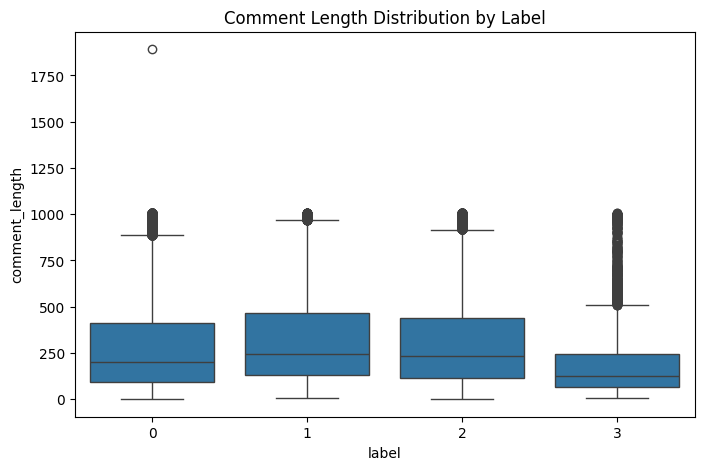

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='comment_length', data=train)
plt.title("Comment Length Distribution by Label")
plt.show()

- Class 0 → Median ≈ 199  
- Class 1 → Median ≈ 246  
- Class 2 → Median ≈ 232  
- Class 3 → Median ≈ 128  

- Class **1 and 2** have **longer comments**
- Class **0** has **moderate-length comments**
- Class **3** has **significantly shorter comments**

- Class 3 also shows:
  - Lower median
  - Smaller interquartile range
  - More compact distribution

- Longer comments (Class 1 & 2) are typically:
  - Argumentative
  - Explanatory
  - Emotionally expressive

- Short comments (Class 3) are often:
  - Aggressive
  - Sarcastic
  - Direct or reaction-based

---
From the boxplot:

- Clear separation between Class 3 and others  
- Overlap exists between Class 1 and 2  
- Presence of outliers (very long comments)

## Words Analysis 

In [26]:
train['word_count'] = train['comment'].fillna("").apply(lambda x: len(x.split()))
train.groupby('label')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,114173.0,51.187339,46.289364,0.0,16.0,35.0,71.0,315.0
1,15918.0,57.233446,45.505920,1.0,22.0,42.0,80.0,219.0
2,62440.0,54.901537,45.302864,1.0,20.0,40.0,76.0,206.0
3,5469.0,34.978424,34.361022,1.0,13.0,24.0,44.0,199.0


In [27]:
train['word_count']

0          20
1         110
2         133
3          15
4          40
         ... 
197995     21
197996     18
197997     23
197998     22
197999     35
Name: word_count, Length: 198000, dtype: int64

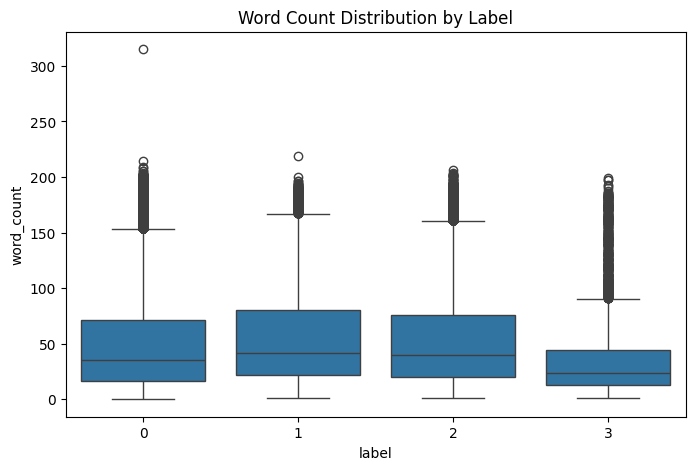

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='word_count', data=train)
plt.title("Word Count Distribution by Label")
plt.show()

- Class 0 → Moderate word count  
- Class 1 → Highest word count  
- Class 2 → High word count  
- Class 3 → Lowest word count

- Class **1 and 2** comments contain **more words**
- Class **0** has **moderate word usage**
- Class **3** comments are **very short (few words)**

- Class 1 & 2:
  - More descriptive and detailed  
  - Often involve explanations or arguments  

- Class 3:
  - Short, direct, and reactionary  
  - Often aggressive or sarcastic  

---
- Clear separation for **Class 3 (lowest word count)**
- Significant overlap between **Class 1 and 2**
- Similar pattern as comment length → confirms consistency

## Sample Comments Analysis
To better understand each class, I examine actual comment examples.

In [29]:
for lbl in sorted(train['label'].unique()):
    print("\n" + "="*50)
    print(f"Label {lbl} Sample Comments")
    print("="*50)
    
    samples = train[train['label'] == lbl]['comment'].dropna().sample(5, random_state=42)
    for i, comment in enumerate(samples, 1):
        print(f"\nExample {i}:")
        print(comment)
        print(f"Character Length: {len(comment)}")
        print(f"Word Count: {len(comment.split())}")


Label 0 Sample Comments

Example 1:
Well, look at the source. I've gritted my teeth and listened through what she calls her talk radio show a nevvu few times. The discussion mostly amounted to insulting and name-calling, with very little actual content other than her opinions.
Character Length: 241
Word Count: 40

Example 2:
Good luck with wi that.
Character Length: 23
Word Count: 5

Example 3:
You're one to talk about spinning Doc.  Buick USA sales have been increasing, not decreasing over at least the past 6 years, and per the article, it is a niche brand fo GM in the USA.  Countless parts are manufactured in China, even for your beloved Hyundai.  So tell me what vehicles assembled in the USA have Chinese engines and what has made them so "scary"?  Any "scarier" than the early Hyundai Theta engines that rolled off the floor in Alabama?  My local restaurant makes an excellent combo #1, the Chinese are quite capable people.
Character Length: 539
Word Count: 95

Example 4:
everyobdy is

###  Class 0 — General Comments
- Neutral tone  
- Everyday conversation  
- Informal and non-offensive  

---

###  Class 1 — Identity-Based Content
- Mentions race, religion, gender, etc.  
- Emotionally charged  
- Often subjective or opinion-based  

---

###  Class 2 — Political / Systemic Criticism
- Structured and detailed  
- Mentions policies, systems, or governance  
- Argumentative in nature  

---

###  Class 3 — Aggressive / Toxic Comments
- Very short and direct  
- Sarcastic or insulting tone  
- Reaction-based (low context)  

---

- Class differences are not just numerical but **semantic**
- Text meaning plays a crucial role in classification  
- Structural patterns (length, tone) align with earlier EDA findings  


## Capitalization Analysis (Uppercase Ratio)

In [30]:
train['uppercase_ratio'] = train['comment'].fillna("").apply(
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
)

train.groupby('label')['uppercase_ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,114173.0,0.035707,0.041075,0.0,0.017544,0.027083,0.041667,0.954023
1,15918.0,0.034611,0.041693,0.0,0.018868,0.027586,0.040201,0.841317
2,62440.0,0.033659,0.038997,0.0,0.017920,0.026599,0.039024,0.904762
3,5469.0,0.036001,0.048242,0.0,0.016667,0.026247,0.041096,0.802920


Uppercase ratio is not a strong discriminative feature.

We can probably ignore it.
This suggests that capitalization is not a strong distinguishing feature for classification.

## Frequent Word Analysis Using CountVectorizer

In [31]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_words(label, n=15):
    subset = train[train['label'] == label]['comment'].fillna("")
    
    vectorizer = CountVectorizer(stop_words='english', max_features=1000)
    X = vectorizer.fit_transform(subset)
    
    word_counts = pd.DataFrame({
        'word': vectorizer.get_feature_names_out(),
        'count': X.sum(axis=0).A1
    })
    
    return word_counts.sort_values(by='count', ascending=False).head(n)

for lbl in sorted(train['label'].unique()):
    print("\n==============================")
    print(f"Top words for Label {lbl}")
    print("==============================")
    print(get_top_words(lbl))


Top words for Label 0
           word  count
639      people  18417
463        just  15785
505        like  15466
907       trump  13479
255         don  13445
890        time  10266
886       think   9334
363        good   8846
472        know   8756
759       right   8269
996       years   8021
239         did   7846
533        make   7640
368  government   7198
955         way   7182

Top words for Label 1
        word  count
966    white   6613
646   people   4920
93     black   3827
470     just   2594
510     like   2523
586  muslims   2391
585   muslim   2289
253      don   2248
909    trump   2233
974    women   1768
747    right   1618
885    think   1446
202  country   1362
945     want   1277
709   racist   1268

Top words for Label 2
           word  count
901       trump  18370
644      people  12288
519        like  11643
472        just  11266
255         don   8211
751       right   5537
874       think   5446
882        time   5401
483        know   5318
362        go

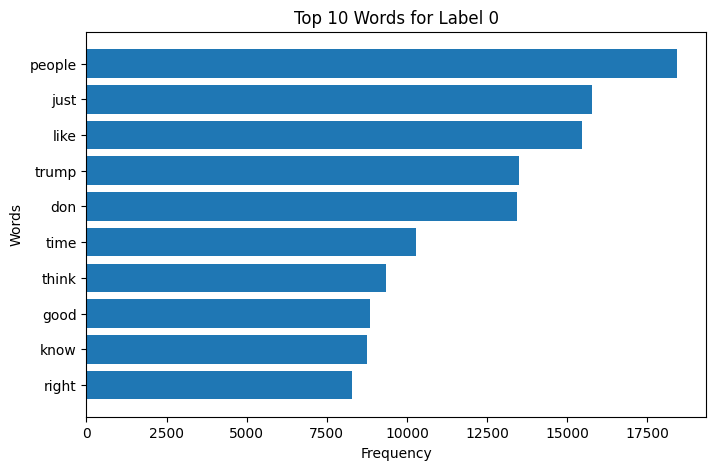

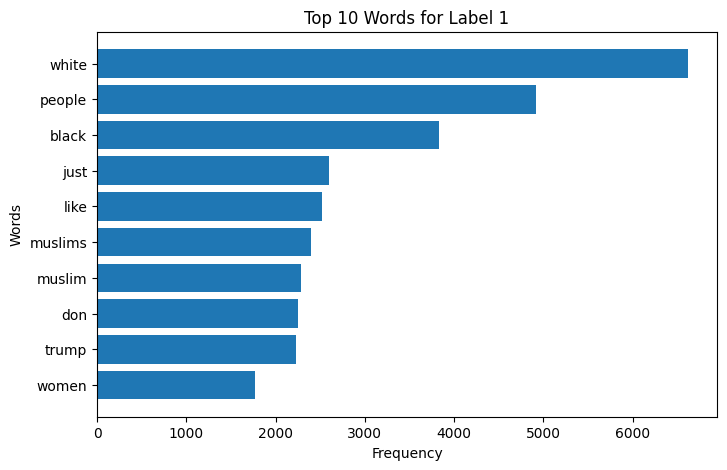

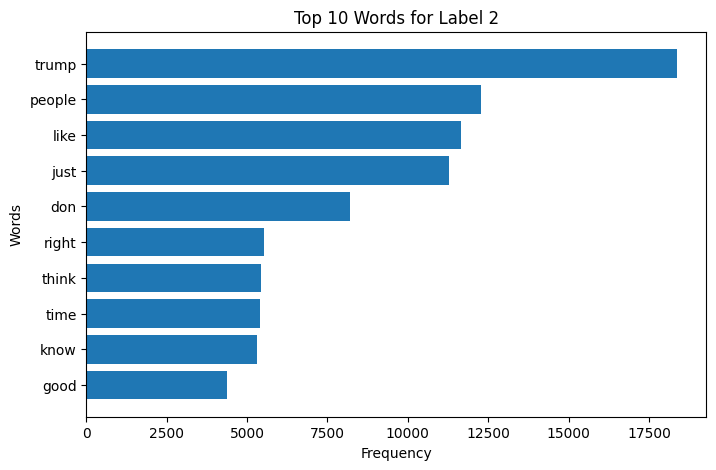

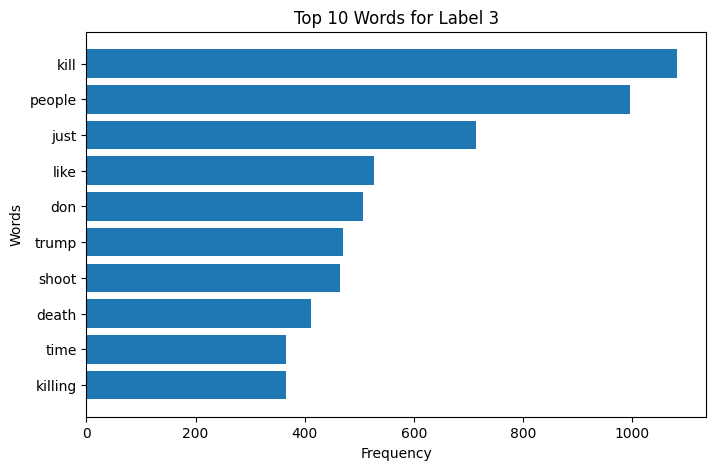

In [32]:
def plot_top_words(label, n=10):
    subset = train[train['label'] == label]['comment'].fillna("")
    
    vectorizer = CountVectorizer(stop_words='english', max_features=1000)
    X = vectorizer.fit_transform(subset)
    
    word_counts = pd.DataFrame({
        'word': vectorizer.get_feature_names_out(),
        'count': X.sum(axis=0).A1
    })
    
    top_words = word_counts.sort_values(by='count', ascending=False).head(n)
    
    
    plt.figure(figsize=(8,5))
    plt.barh(top_words['word'], top_words['count'])
    plt.gca().invert_yaxis()
    plt.title(f"Top {n} Words for Label {label}")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()


for lbl in sorted(train['label'].unique()):
    plot_top_words(lbl)

| Label | Theme                 |
| ----- | --------------------- |
| 0     | General conversation  |
| 1     | Identity-based speech |
| 2     | Political criticism   |
| 3     | Violent / aggressive  |



###  Class 0 — General Comments
- Common conversational words  
- Neutral and generic vocabulary  

---

###  Class 1 — Identity-Based Content
- Words related to:
  - Race  
  - Religion  
  - Gender  
- Indicates sensitive or identity-focused discussions  

---

###  Class 2 — Political / Systemic
- Words related to:
  - Government  
  - Policies  
  - Society  
- Structured and topic-driven vocabulary  

---

###  Class 3 — Aggressive / Toxic
- Presence of:
  - Strong negative words  
  - Slang or insults  
- Short and impactful vocabulary  

---

- Each class has **distinct word distributions**  
- Confirms that **text content is the strongest signal**  


## Engagement Feature Analysis (Upvotes and Downvotes)

In [33]:
train['upvote'].median()

1.0

In [34]:
train.groupby('label')['upvote'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,114173.0,2.404833,4.601209,0.0,0.0,1.0,3.0,201.0
1,15918.0,2.850107,6.047758,0.0,0.0,1.0,3.0,166.0
2,62440.0,2.967825,5.612198,0.0,0.0,1.0,4.0,163.0
3,5469.0,2.035656,3.765532,0.0,0.0,1.0,2.0,44.0


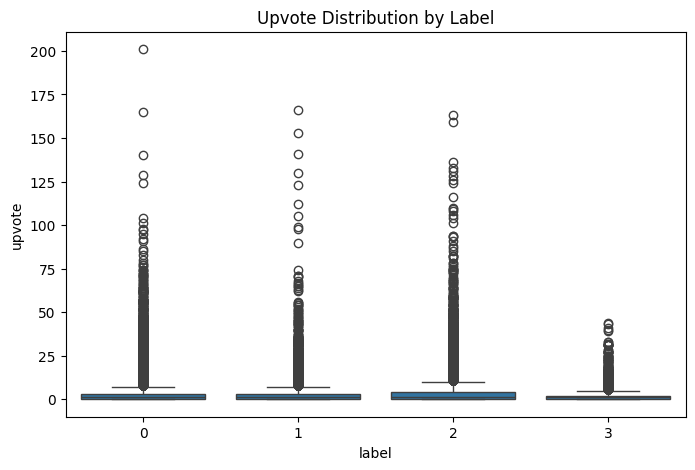

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='upvote', data=train)
plt.title("Upvote Distribution by Label")
plt.show()

In [36]:
train.groupby('label')['downvote'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,114173.0,0.575294,1.863328,0.0,0.0,0.0,0.0,101.0
1,15918.0,0.802048,2.171240,0.0,0.0,0.0,1.0,68.0
2,62440.0,0.811723,2.336218,0.0,0.0,0.0,1.0,107.0
3,5469.0,0.514171,1.517042,0.0,0.0,0.0,0.0,26.0


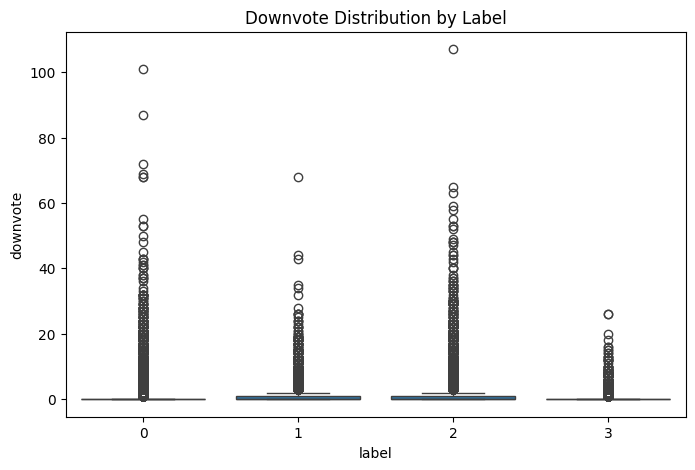

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='downvote', data=train)
plt.title("Downvote Distribution by Label")
plt.show()

- Median upvotes and downvotes are **close to zero across all classes**
- Distribution is **highly skewed**
- Most comments receive **very low engagement**


Upvote and downvote distributions are heavily skewed with most values concentrated at zero.

Median upvotes and downvotes are identical across classes, indicating limited discriminative power.

Although mean differences exist, the variance is high and dominated by outliers.

Therefore, engagement features may provide weak signal and should be transformed (e.g., log transformation) to reduce skewness.

## Identity Attribute Analysis

In [38]:
for col in ['race', 'religion', 'gender', 'disability']:
    print("\n==============================")
    print(f"{col} by label")
    print("==============================")
    print(pd.crosstab(train[col], train['label'], normalize='columns'))


race by label
label          0         1         2         3
race                                          
asian   0.024094  0.027559  0.020899  0.021467
black   0.025701  0.202832  0.038029  0.024150
latino  0.011582  0.015142  0.009799  0.005367
none    0.871032  0.464718  0.820406  0.863148
other   0.028575  0.037023  0.031040  0.032200
white   0.039016  0.252726  0.079827  0.053667

religion by label
label             0         1         2         3
religion                                         
atheist    0.003593  0.005376  0.003906  0.005367
buddhist   0.001818  0.002953  0.001165  0.000894
christian  0.146257  0.163537  0.102645  0.065295
hindu      0.002114  0.002196  0.001165  0.000894
jewish     0.014710  0.050954  0.014389  0.011628
muslim     0.040791  0.237280  0.050158  0.088551
none       0.783024  0.521124  0.817322  0.817531
other      0.007693  0.016581  0.009250  0.009839

gender by label
label               0         1         2         3
gender               

Class 1 shows significantly higher proportions of race, religion, and gender references compared to other classes

| Feature                    | Strong Signal For |
| -------------------------- | ----------------- |
| comment_length             | Label 3           |
| word_count                 | Label 3           |
| violence keywords          | Label 3           |
| race/religion/gender flags | Label 1           |
| political words            | Label 2           |
| upvote/downvote            | Weak              |


## Correlation Between Text Length & Engagement

In [39]:
train[['comment_length', 'word_count', 'upvote', 'downvote']].corr()

,comment_length,word_count,upvote,downvote
comment_length,1.000000,0.992543,0.057710,0.017583
word_count,0.992543,1.000000,0.055769,0.015843
upvote,0.057710,0.055769,1.000000,0.314557
downvote,0.017583,0.015843,0.314557,1.000000


In [40]:
for col in ['emoticon_1','emoticon_2','emoticon_3']:
    print(col)
    print(train[col].value_counts())
    print()

emoticon_1
emoticon_1
0     169078
1      17683
2       5799
3       2362
4       1243
5        638
6        374
7        225
8        162
9        102
10        69
11        68
12        40
13        27
15        20
16        20
14        19
19        13
17         9
23         7
22         6
20         5
18         5
36         4
25         4
27         3
24         2
21         2
31         2
30         2
32         2
28         1
46         1
33         1
47         1
39         1
Name: count, dtype: int64

emoticon_2
emoticon_2
0     189891
1       7031
2        822
3        177
4         48
5         21
6          7
8          1
11         1
7          1
Name: count, dtype: int64

emoticon_3
emoticon_3
0     180835
1      13017
2       2777
3        764
4        309
5        132
6         79
7         41
8         14
10        12
9          9
11         4
14         2
13         2
12         2
17         1
Name: count, dtype: int64



In [41]:
for col in ['emoticon_1','emoticon_2','emoticon_3']:
    print("\n=======================")
    print(f"{col} by label")
    print("=======================")
    print(pd.crosstab(train[col], train['label'], normalize='columns'))


emoticon_1 by label
label              0         1         2         3
emoticon_1                                        
0           0.856954  0.857583  0.847261  0.856281
1           0.086132  0.089270  0.095211  0.088316
2           0.028606  0.027830  0.031214  0.025782
3           0.011780  0.010617  0.012300  0.014628
4           0.006464  0.006094  0.006054  0.005485
5           0.003320  0.003141  0.003075  0.003108
6           0.001953  0.001885  0.001730  0.002377
7           0.001261  0.001068  0.000961  0.000731
8           0.000902  0.000628  0.000673  0.001280
9           0.000631  0.000565  0.000304  0.000366
10          0.000420  0.000251  0.000240  0.000366
11          0.000403  0.000314  0.000240  0.000366
12          0.000236  0.000251  0.000144  0.000000
13          0.000175  0.000126  0.000080  0.000000
14          0.000105  0.000000  0.000080  0.000366
15          0.000123  0.000063  0.000064  0.000183
16          0.000105  0.000000  0.000128  0.000000
17        

The emoticon features represent platform-detected symbol group counts rather than raw user emojis.

Across all labels, the majority of comments (~85–95%) contain zero emoticons.

Distribution differences across labels are minimal, suggesting limited discriminative power.

If retained, these features should be simplified into binary presence indicators rather than raw counts.

## Exploring if_1 if_2

In [42]:
for col in ['if_1','if_2']:
    print("\n=======================")
    print(f"{col} by label")
    print("=======================")
    print(pd.crosstab(train[col], train['label'], normalize='columns'))


if_1 by label
label         0         1         2         3
if_1                                         
0      0.792797  0.170248  0.766272  0.795575
4      0.134366  0.415442  0.134753  0.126714
5      0.009074  0.052017  0.012268  0.011154
6      0.022729  0.135381  0.030269  0.024502
7      0.000193  0.001696  0.000304  0.000366
8      0.000018  0.000000  0.000000  0.000000
9      0.000114  0.001068  0.000224  0.000183
10     0.040526  0.221322  0.055637  0.041141
11     0.000070  0.000817  0.000144  0.000366
12     0.000009  0.000063  0.000000  0.000000
249    0.000000  0.000063  0.000000  0.000000
250    0.000000  0.000000  0.000016  0.000000
1232   0.000009  0.000000  0.000000  0.000000
1254   0.000000  0.000063  0.000000  0.000000
1256   0.000000  0.000063  0.000000  0.000000
1257   0.000000  0.000063  0.000000  0.000000
1258   0.000000  0.000000  0.000016  0.000000
1263   0.000000  0.000063  0.000000  0.000000
1267   0.000009  0.000000  0.000000  0.000000
1271   0.000000  0.

Strong class separation is observed in internal features if_1 and if_2.
These features appear to encode platform-level internal categorization signals.

Importantly, these variables represent categorical codes rather than continuous numeric values.

Therefore, treating them as numeric features is inappropriate and may degrade model performance.

They should be handled as categorical variables using one-hot encoding.

# MileStone-Code

In [43]:
train['comment'].str.strip().eq('').sum()

np.int64(0)

M-2 Q-2

In [44]:
train['created_date']=pd.to_datetime(train['created_date'])


In [45]:
train['created_date'].dt.month_name().value_counts()


created_date
May          23573
March        21280
April        20143
February     19526
January      18983
December     15309
August       14223
October      13925
June         13426
November     13417
September    12373
July         11822
Name: count, dtype: int64

M-2 Q3

In [46]:
train['total_emoticons']=train['emoticon_1']+train['emoticon_2']+train['emoticon_3']

In [47]:
train['total_emoticons'].max()

60

M-2 Q4

In [48]:
lst=[]
def count(x):
    lst.append(len(x))

train[train['label']==3]['comment'].apply(count)
print(np.median(lst))

128.0


M-2 Q5

In [49]:
train[train['upvote']==10]

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,comment_length,word_count,uppercase_ratio,total_emoticons
40,2023-02-16 03:05:21.745646+00:00,39,0,0,0,10,0,0,10,NaN,NaN,NaN,False,"Now that I poisoned the pond, I am not going t...",3,62,14,0.047619,0
125,2024-04-19 22:20:41.590714+00:00,72,0,0,0,10,0,4,4,none,none,none,False,Trudeau seems OK with risking the huge number ...,0,288,47,0.065744,0
330,2023-10-09 19:19:17.048038+00:00,39,1,0,0,10,2,4,10,none,none,none,False,Lots of us are in agreement with much of what ...,2,276,48,0.018051,1
400,2023-10-22 05:39:23.399951+00:00,72,0,0,0,10,1,0,4,NaN,NaN,NaN,False,this isn't about the Democrats really.. It's a...,0,124,21,0.056000,0
493,2023-10-29 22:22:45.651334+00:00,72,11,0,0,10,1,0,4,NaN,NaN,NaN,False,Do lone wolves become radiclaized before or af...,0,70,12,0.014085,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197067,2024-04-27 05:07:48.694567+00:00,72,0,2,0,10,4,0,10,NaN,NaN,NaN,False,220% duty is almost as ludicrous as the $134 m...,2,81,15,0.024390,2
197163,2023-07-30 02:10:25.018517+00:00,72,0,0,0,10,5,0,10,NaN,NaN,NaN,False,Yakabuski (the author) appears to know absolut...,2,740,132,0.033738,0
197393,2023-07-16 23:38:56.608209+00:00,72,1,0,1,10,1,0,4,NaN,NaN,NaN,False,I stand corrected.. \nJustin will tax any Cana...,0,167,29,0.047619,2
197395,2024-05-05 09:08:17.050347+00:00,72,0,0,0,10,0,0,6,NaN,NaN,NaN,False,"20,000+ submissions. Are these proposalsl ook...",0,90,13,0.010989,0


In [50]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

scaler.fit_transform(train[['upvote']])

scaler.transform([[10]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[0.04975124]])

M2- Q6

In [51]:
lst=[]
def avgCount(x):
    lst.append(len(x.split()))
train[train['label']==1]['comment'].apply(avgCount)
np.mean(lst)

np.float64(57.23344641286594)

M2-Q7

In [52]:
train['comment'].str.contains("Trump",case=False).sum()

24398

M2-Q8

In [53]:
words=['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
text=train['comment'].loc[0].split()
lst=[ i  for i in text if i.lower() not in words ]
len(lst)

12

M2-Q9

In [54]:
train['comment'].str.lower().str.split().explode().nunique()

425413

M2-Q-10

In [55]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer(
#     stop_words='english',
#     min_df=5,
#     ngram_range=(1, 2)
# )

# vectorizer.fit_transform(train['comment'].fillna(""))


# len(vectorizer.get_feature_names_out())

# Feature engeering

In [56]:
train['comment']= train['comment'].fillna("")
test['comment']=test['comment'].fillna("")


train['word_count'] = train['comment'].apply(lambda x : len(x.split()))
test['word_count'] = test['comment'].apply(lambda x : len(x.split()))

train['log_upvote'] = np.log1p(train['upvote'])
train['log_downvote'] = np.log1p(train['downvote'])

test['log_upvote'] = np.log1p(test['upvote'])
test['log_downvote'] = np.log1p(test['downvote'])


In [57]:
numeric_cols = ['word_count','log_upvote','log_downvote']
cat_cols = ["race", "religion", "gender","disability","if_1","if_2"]
text_col = "comment"

### 1. Text Features
- Raw comment text used for TF-IDF vectorization  
- Captures semantic meaning and word patterns  

---

### 2. Length-Based Features
- `word_count`: Number of words in a comment  


- Short comments → Class 3  
- Long comments → Class 1 & 2  

---

### 3. Engagement Features (Transformed)

- `log_upvote = log1p(upvote)`  
- `log_downvote = log1p(downvote)`
- 
### 4. Categorical Features

- race, religion, gender, disability  
- if_1, if_2  

 
- One-hot encoding applied  


In [58]:
X=train.drop('label',axis=1)
y=train["label"]


# Train-Validation Split

In [59]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y, random_state=42)

In [60]:
X_train.shape, y_train.shape


((158400, 20), (158400,))

# Text Vectorization (TF-IDF)
To convert text data into numerical form, I use TF-IDF vectorization.

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

word_tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1,2),
    max_features=50000,
    min_df=3,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=100000,
    min_df=3,
    sublinear_tf=True
)

text_pipeline = FeatureUnion([
    ('word', word_tfidf),
    ('char', char_tfidf)
])


### 1. Word-Level TF-IDF
- Uses unigrams and bigrams  
- Captures word meaning and context  

---

### 2. Character-Level TF-IDF
- Uses character n-grams (3–5)  
- Captures:
  - Misspellings  
  - Slang  
  - Toxic patterns  

---

I combine both using **FeatureUnion** to capture:
- Semantic meaning (word-level)  
- Structural patterns (character-level)  

---


# Model Pipeline

In [62]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_pipeline=Pipeline([
    ('scaler',StandardScaler())
])


cat_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="none")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


In [63]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("text", text_pipeline, text_col),
    ("num", num_pipeline, numeric_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Model Evaluation Function

In [64]:
from sklearn.metrics import classification_report ,accuracy_score,f1_score

def model_pipe(model):
    return Pipeline([
        ('preprocessor',preprocessor),
        ('model',model)
    ])

def model_fit_score(model):
    pipe=model_pipe(model)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    print(classification_report(y_test,y_pred))
    print("f1: ",f1_score(y_test,y_pred,average="macro"))


# Modal Training

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier

## Logistic Regression

In [66]:
model1 = LogisticRegression(random_state=42)
# model_fit_score(model1)

## SGDClassifier

In [67]:
model2=SGDClassifier(
    alpha=5e-06,
    l1_ratio=0.15,
    max_iter=5000,
    random_state=42
)
model_fit_score(model2)

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22835
           1       0.79      0.74      0.76      3183
           2       0.86      0.92      0.89     12488
           3       0.74      0.56      0.64      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.79      0.81     39600
weighted avg       0.91      0.91      0.91     39600

f1:  0.8122603724141835


## LinearSVC

In [68]:
model3 = LinearSVC(random_state=42)
# model_fit_score(model3)

## LightGBM

In [69]:
model4=LGBMClassifier(random_state=42)
# model_fit_score(model4)

# Hyperparameter tunning

In [70]:
# param_dist = {
#     "model__loss": ["hinge", "log_loss"],
#     "model__penalty": ["l2", "elasticnet"],
#     "model__alpha": [1e-6, 5e-6, 1e-5, 5e-5],
#     "model__l1_ratio": [0.1, 0.15, 0.2],
#     "model__max_iter": [3000, 5000],
#     "model__class_weight": [
#         "balanced",
#         {0:1, 1:1.5, 2:1, 3:2},
#         {0:1, 1:1.5, 2:1, 3:2.5}
#     ]
# }

In [71]:
# from sklearn.model_selection import RandomizedSearchCV

# sgd = SGDClassifier(random_state=42)
# pipe = model_pipe(sgd)


# rscv = RandomizedSearchCV(
#     estimator=pipe,
#     param_distributions=param_dist,
#     n_iter=5,
#     scoring="f1_macro",
#     cv=3,
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )
# rscv.fit(X_train, y_train)

In [72]:
# print("Best Params:", rscv.best_params_)
# print("Best CV Score:", rscv.best_score_)

In [73]:
# param_dist_svc = {
#     "model__C": [0.5, 1.0, 2.0, 3.0],
#     "model__class_weight": [
#         "balanced",
#         {0:1, 1:1.5, 2:1, 3:2},
#         {0:1, 1:1.5, 2:1, 3:2.5}
#     ],
#     "model__max_iter": [3000, 5000]
# }

In [74]:
# svc = LinearSVC(random_state=42)

# pipe_svc = model_pipe(svc)

# rscv2 = RandomizedSearchCV(
#     estimator=pipe_svc,
#     param_distributions=param_dist_svc,
#     n_iter=5,
#     scoring="f1_macro",
#     cv=3,
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )
# rscv2.fit(X_train, y_train)

In [75]:
# print("Best Params:", rscv2.best_params_)
# print("Best CV Score:", rscv2.best_score_)

# Final Model

In [76]:
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SGDClassifier(
        loss='log_loss',
        penalty='elasticnet',
        alpha=5e-06,
        l1_ratio=0.15,
        class_weight={0:1, 1:1.5, 2:1, 3:2.5},
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    ))
])

In [77]:
# final_model = model_pipe(
#     LinearSVC(
#         C=0.5,
#         class_weight="balanced",
#         max_iter=3000,
#         random_state=42
#     )
# )

# Submission

In [78]:
final_model.fit(X,y)
test_pred=final_model.predict(test)


In [79]:
submission = sample.copy()
submission["label"] = test_pred
submission.head()

,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2


In [80]:
submission.to_csv("submission.csv", index=False)